In [ ]:
# --- 0. Instalasi Library (jika diperlukan) ---
!pip install pandas scikit-learn numpy matplotlib seaborn graphviz
# graphviz diperlukan untuk visualisasi pohon keputusan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- 1. Impor Library yang Diperlukan ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree # plot_tree untuk visualisasi pohon
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io # Digunakan untuk mengunggah file langsung

# Untuk visualisasi Decision Tree (opsional, plot_tree dari sklearn lebih mudah di Colab)
# from IPython.display import Image
# import graphviz
# import pydotplus

print("Library berhasil diimpor.")


Library berhasil diimpor.


In [ ]:
# --- 2. Memuat Data ---

# Pilihan A: Unggah file CSV langsung ke sesi Colab
print("\n--- Mengunggah File Data ---")
from google.colab import files
uploaded = files.upload()

file_name = 'personality_datasert.csv'
if file_name not in uploaded:
    print(f"Error: File '{file_name}' tidak ditemukan setelah diunggah.")
    print("Pastikan Anda mengunggah file dengan nama yang benar atau sesuaikan 'file_name' di kode.")
    exit()

try:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"Data '{file_name}' berhasil dimuat.")
    print("Bentuk data:", df.shape)
    print("5 baris pertama data:")
    print(df.head())
    print("\nInformasi kolom data (untuk memeriksa tipe data):")
    df.info() # Penting untuk melihat tipe data asli setiap kolom
except Exception as e:
    print(f"Error saat membaca file CSV: {e}")
    exit()

# --- ATAU ---

# Pilihan B: Mount Google Drive (jika file ada di Google Drive Anda)
# Nonaktifkan Pilihan A di atas jika Anda menggunakan ini.
# from google.colab import drive
# drive.mount('/content/drive')
# try:
#     # SESUAIKAN PATH INI dengan lokasi file Anda di Google Drive
#     file_path = '/content/drive/MyDrive/path/ke/folder/personality_datasert.csv'
#     df = pd.read_csv(file_path)
#     print(f"Data dari Google Drive '{file_path}' berhasil dimuat.")
#     print("Bentuk data:", df.shape)
#     print("5 baris pertama data:")
#     print(df.head())
#     print("\nInformasi kolom data (untuk memeriksa tipe data):")
#     df.info()
# except FileNotFoundError:
#     print(f"Error: File tidak ditemukan di '{file_path}'. Pastikan path sudah benar.")
#     exit()
# except Exception as e:
#     print(f"Error saat membaca file CSV dari Google Drive: {e}")
#     exit()


--- Mengunggah File Data ---


Saving personality_datasert.csv to personality_datasert.csv
Data 'personality_datasert.csv' berhasil dimuat.
Bentuk data: (2900, 8)
5 baris pertama data:
   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0               4.0         No                      4.0            6.0   
1               9.0        Yes                      0.0            0.0   
2               9.0        Yes                      1.0            2.0   
3               0.0         No                      6.0            7.0   
4               3.0         No                      9.0            4.0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                 13.0             5.0   Extrovert  
1                       Yes                  0.0             3.0   Introvert  
2                       Yes                  5.0             2.0   Introvert  
3                        No                 14.0             8.0   Extrovert  
4     

In [ ]:
# --- 3. Prapemrosesan Data ---

# Definisi Kolom secara Eksplisit
# Fitur (X) dan Target (y)
target_column = 'Personality' # Kolom target yang sudah ditentukan
feature_columns = [
    'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
    'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
    'Post_frequency'
]

# Memastikan semua kolom yang diperlukan ada di DataFrame
if not all(col in df.columns for col in feature_columns + [target_column]):
    missing_cols = [col for col in feature_columns + [target_column] if col not in df.columns]
    print(f"\nError: Kolom yang dibutuhkan tidak ditemukan di file CSV Anda: {missing_cols}")
    print("Pastikan nama kolom di file CSV Anda sesuai persis dengan yang didefinisikan di kode.")
    print("Kolom yang tersedia di data Anda:", df.columns.tolist())
    exit()

print(f"\nKolom target yang digunakan: '{target_column}'")
print(f"Kolom fitur yang digunakan: {feature_columns}")

# Memisahkan fitur (X) dan target (y) berdasarkan definisi eksplisit
X = df[feature_columns].copy() # Tambahkan .copy() untuk memastikan X adalah salinan independen
y = df[target_column].copy()

# Mengidentifikasi kolom kategorikal dan numerik di antara fitur yang dipilih
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

print(f"\nKolom Kategorikal yang terdeteksi di antara fitur: {list(categorical_cols)}")
print(f"Kolom Numerik yang terdeteksi di antara fitur: {list(numerical_cols)}")

# Mengkodekan kolom target (jika string 'ekstrovert'/'introvert')
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_ # Simpan nama kelas asli untuk visualisasi
print(f"\nNilai target unik setelah encoding: {np.unique(y_encoded)}")
print(f"Mapping target: {list(le.classes_)} -> {np.unique(y_encoded).tolist()}")

# Menangani nilai yang hilang (Missing Values)
print("\nMenangani nilai yang hilang...")
# *** BARIS INI DITAMBAHKAN ***
print(f"Jumlah total nilai hilang pada fitur sebelum imputasi: {X.isnull().sum().sum()}")
print("Detail nilai hilang per kolom sebelum imputasi:")
print(X.isnull().sum())
# *** END BARIS DITAMBAHKAN ***

imputer_numerical = SimpleImputer(strategy='mean')
if len(numerical_cols) > 0:
    X.loc[:, numerical_cols] = imputer_numerical.fit_transform(X[numerical_cols])
    print(f"Nilai hilang pada kolom numerik diisi dengan rata-rata.")

imputer_categorical = SimpleImputer(strategy='most_frequent')
if len(categorical_cols) > 0:
    X.loc[:, categorical_cols] = imputer_categorical.fit_transform(X[categorical_cols])
    print(f"Nilai hilang pada kolom kategorikal diisi dengan modus.")

print(f"Jumlah total nilai hilang setelah imputasi: {X.isnull().sum().sum()}")


# One-Hot Encoding untuk kolom kategorikal
print("\nMelakukan One-Hot Encoding pada kolom kategorikal...")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Menskalakan Fitur Numerik (setelah one-hot encoding jika ada kolom kategorikal baru)
print("\nMenskalakan fitur...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_processed = pd.DataFrame(X_scaled, columns=X.columns)
print("Fitur setelah prapemrosesan dan penskalaan (5 baris pertama):")
print(X_processed.head())

# Simpan nama fitur setelah one-hot encoding untuk visualisasi
feature_names = X_processed.columns.tolist()


Kolom target yang digunakan: 'Personality'
Kolom fitur yang digunakan: ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']

Kolom Kategorikal yang terdeteksi di antara fitur: ['Stage_fear', 'Drained_after_socializing']
Kolom Numerik yang terdeteksi di antara fitur: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

Nilai target unik setelah encoding: [0 1]
Mapping target: ['Extrovert', 'Introvert'] -> [0, 1]

Menangani nilai yang hilang...
Jumlah total nilai hilang pada fitur sebelum imputasi: 0
Detail nilai hilang per kolom sebelum imputasi:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64
Nilai hilang pada kolom numerik diisi dengan rata-rata.
Nilai hilan

In [ ]:
# --- 4. Membagi Data ---
print("\nMembagi data menjadi set pelatihan dan pengujian...")
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"Ukuran data latih (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Ukuran data uji (X_test, y_test): {X_test.shape}, {y_test.shape}")


Membagi data menjadi set pelatihan dan pengujian...
Ukuran data latih (X_train, y_train): (2320, 7), (2320,)
Ukuran data uji (X_test, y_test): (580, 7), (580,)


In [ ]:
# --- 5. Melatih Model Decision Tree ---
print("\n--- Melatih Model Decision Tree ---")
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5) # Batasi kedalaman untuk visualisasi yang lebih mudah
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
y_proba_dt = dt_classifier.predict_proba(X_test)[:, 1] # Probabilitas kelas positif (ekstrovert/1)


--- Melatih Model Decision Tree ---


In [ ]:
# --- 6. Mengevaluasi Model Decision Tree ---
print("\n--- Hasil Evaluasi Model Decision Tree ---")
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(f"Akurasi Decision Tree: {accuracy_dt:.4f}")
print(f"Presisi Decision Tree: {precision_dt:.4f}")
print(f"Recall Decision Tree: {recall_dt:.4f}")
print(f"F1-Score Decision Tree: {f1_dt:.4f}")
print("Classification Report Decision Tree:\n", classification_report(y_test, y_pred_dt, target_names=class_names))


--- Hasil Evaluasi Model Decision Tree ---
Akurasi Decision Tree: 0.9172
Presisi Decision Tree: 0.8953
Recall Decision Tree: 0.9397
F1-Score Decision Tree: 0.9170
Classification Report Decision Tree:
               precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



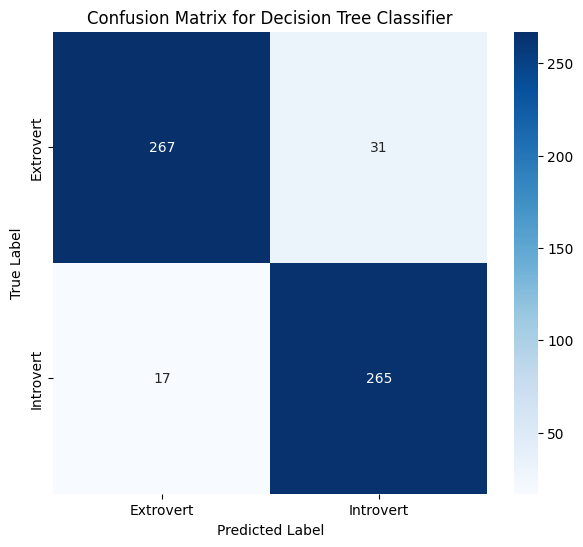

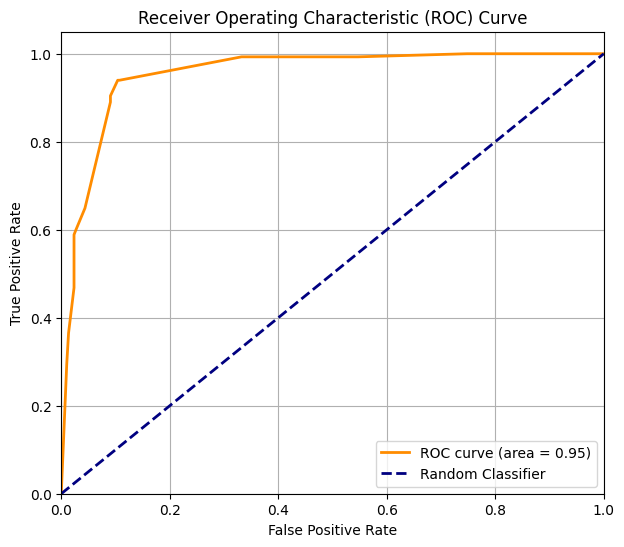

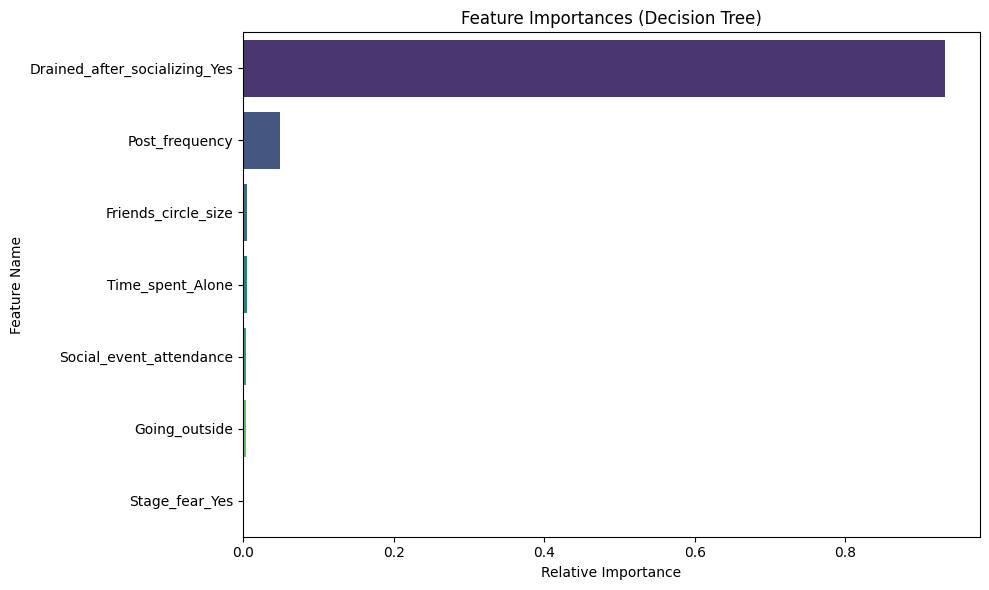


--- Visualisasi Pohon Keputusan ---


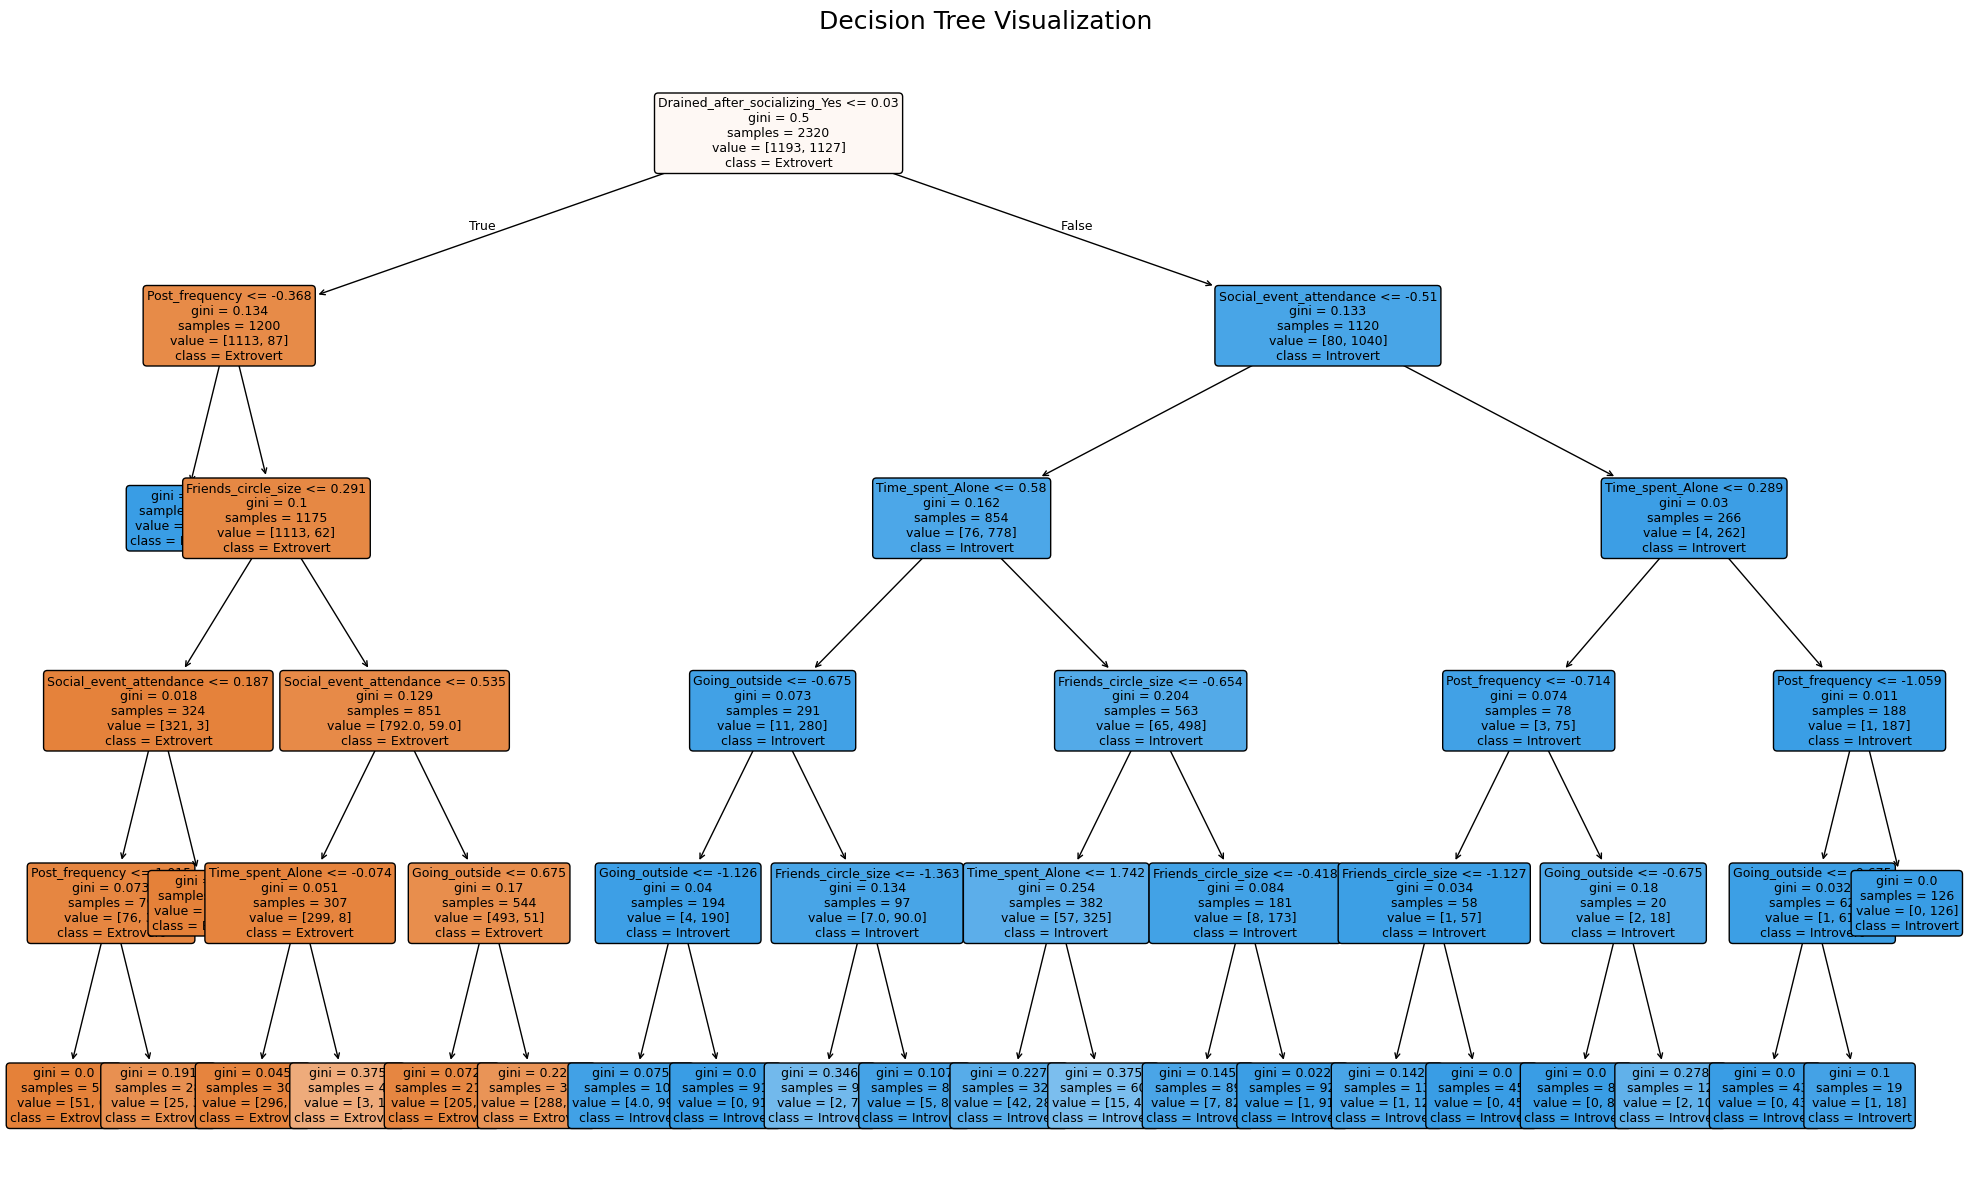


Analisis klasifikasi Decision Tree selesai.


In [ ]:
# --- 7. Visualisasi Hasil ---

# Visualisasi 1: Confusion Matrix Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualisasi 2: ROC Curve dan AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Visualisasi 3: Feature Importance Bar Chart
if len(feature_names) > 0 and dt_classifier.feature_importances_.sum() > 0:
    importances = dt_classifier.feature_importances_
    indices = np.argsort(importances)[::-1] # Urutkan dari yang paling penting

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances (Decision Tree)")
    # Menggunakan 'hue' dan 'legend=False' untuk mengatasi FutureWarning
    sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], hue=[feature_names[i] for i in indices], palette='viridis', legend=False)
    plt.xlabel("Relative Importance")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()
else:
    print("\nTidak ada fitur untuk divisualisasikan Feature Importance atau semua fitur memiliki kepentingan 0.")


# Visualisasi 4: Pohon Keputusan (Decision Tree Visualization)
print("\n--- Visualisasi Pohon Keputusan ---")
try:
    fig, ax = plt.subplots(figsize=(25, 15)) # Atur ukuran sesuai kebutuhan untuk visibilitas
    plot_tree(dt_classifier,
              feature_names=feature_names,
              class_names=class_names,
              filled=True, rounded=True,
              fontsize=9, # Sesuaikan ukuran font jika terlalu kecil/besar
              ax=ax)
    plt.title('Decision Tree Visualization', fontsize=18)
    plt.show()

except Exception as e:
    print(f"Gagal memvisualisasikan pohon keputusan: {e}")
    print("Pastikan library yang diperlukan sudah terinstal dan berjalan dengan baik.")


print("\nAnalisis klasifikasi Decision Tree selesai.")